In [1]:
!pip install wordcloud

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
import re
from wordcloud import WordCloud
import numpy as np
import nltk
from nltk.corpus import opinion_lexicon

# 1. Import Data

In [3]:
csv_paths = list(Path("../Dataset/data_new_approach/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
marcus_by_goldman_sachs__combined_us.csv
chase__combined_us.csv
bank_of_america__combined_us.csv
wells_fargo__combined_us.csv
citi__combined_us.csv


In [4]:
# import files
raw = pd.concat(
    [
        pd.read_csv(p, dtype=str).assign(source_file=p.name)
        for p in csv_paths
    ],
    ignore_index=True
)

# 2. Data Overview

In [ ]:
raw.info()

In [ ]:
raw.describe(include = "all")

In [ ]:
raw.head()

In [6]:
platform_counts = (
    raw
    .groupby("platform")
    .size()
    .reset_index(name="n_reviews")
)

platform_counts

,platform,n_reviews
0,app_store,2450
1,google_play,3000


In [7]:
missing_raw = (
    raw
    .isna()
    .sum()
    .reset_index()
)

missing_raw.columns = ["variable", "n_missing"]

missing_raw = (
    missing_raw
    .sort_values("n_missing", ascending=False)
    .reset_index(drop=True)
)

missing_raw

,variable,n_missing
0,app_id,3000
1,title,3000
2,version,3000
3,appVersion,2676
4,package,2450
5,thumbsUpCount,2450
6,platform,0
7,storefront,0
8,review_id,0
9,date,0


In [8]:
missing_by_platform = (
    raw
    .groupby("platform")
    .agg(lambda col: col.isna().sum())
    .reset_index()
)

missing_by_platform

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,0,0,0,0,0,0,0,0,0,2450,2450,2450,0
1,google_play,0,3000,0,0,0,0,3000,0,3000,0,0,226,0


In [9]:
raw["raw_text"] = (
    raw["title"].fillna("") + " " + raw["review"].fillna("")
)

raw["raw_length_words"] = (
    raw["raw_text"]
    .str.count(r"\S+")
)

In [10]:
raw["raw_length_words"].describe()

count    5450.000000
mean       22.044587
std        29.047547
min         1.000000
25%         4.000000
50%        11.000000
75%        28.000000
max       377.000000
Name: raw_length_words, dtype: float64

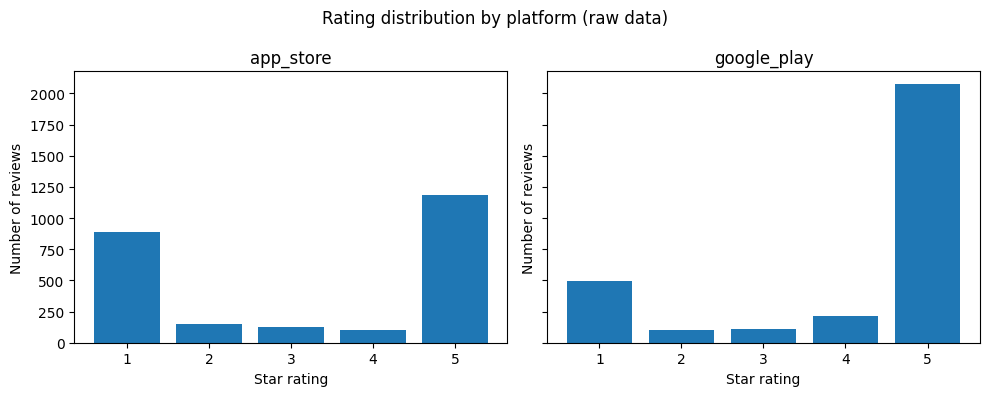

In [11]:
# Count the ratings by platform
rating_counts = (
    raw
    .groupby(["platform", "rating"])
    .size()
    .reset_index(name="n_reviews")
)

platforms = rating_counts["platform"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(platforms),
    figsize=(10, 4),
    sharey=True
)

if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    data = rating_counts[rating_counts["platform"] == platform]

    ax.bar(data["rating"], data["n_reviews"])
    ax.set_title(platform)
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Number of reviews")

fig.suptitle("Rating distribution by platform (raw data)")
plt.tight_layout()
plt.show()

# 3. Data Preprocessing

## 3.1 Preprocessing for Lexicon Based

In [12]:
df1 = raw.copy()

df1["bank"] = (
    df1["source_file"]
    .str.replace(r"__combined_us\.csv$", "", regex=True)
    .str.replace("_", " ", regex=False)
    .str.title()
)

df1["platform"] = df1["platform"].replace({
    "app_store": "iOS",
    "google_play": "Android"
})

df1.groupby(["bank", "platform"]).size().reset_index(name="n")

,bank,platform,n
0,Bank Of America,Android,600
1,Bank Of America,iOS,490
2,Chase,Android,600
3,Chase,iOS,490
4,Citi,Android,600
5,Citi,iOS,490
6,Marcus By Goldman Sachs,Android,600
7,Marcus By Goldman Sachs,iOS,490
8,Wells Fargo,Android,600
9,Wells Fargo,iOS,490


In [13]:
df2 = df1.copy()

df2["rating"] = pd.to_numeric(df2["rating"], errors="coerce")
df2["date"] = pd.to_datetime(df2["date"], errors="coerce")

rating_summary = df2["rating"].agg(
    Min="min",
    Q1=lambda x: x.quantile(0.25),
    Median="median",
    Mean="mean",
    Q3=lambda x: x.quantile(0.75),
    Max="max"
)

date_summary = df2["date"].agg(
    Min="min",
    Q1=lambda x: x.quantile(0.25),
    Median="median",
    Mean="mean",
    Q3=lambda x: x.quantile(0.75),
    Max="max"
)

print("Rating summary:")
print(rating_summary)

print("\nDate summary:")
print(date_summary)

df2.head()

Rating summary:
Min       1.000000
Q1        1.000000
Median    5.000000
Mean      3.697982
Q3        5.000000
Max       5.000000
Name: rating, dtype: float64

Date summary:
Min                2024-06-06 14:25:49-07:00
Q1       2025-12-24 02:06:11.249999872-07:00
Median      2026-03-21 12:18:06.500000-07:00
Mean     2026-01-10 08:49:03.699183616-07:00
Q3       2026-04-07 13:22:56.750000128-07:00
Max                2026-04-20 09:04:39-07:00
Name: date, dtype: datetime64[ns, UTC-07:00]


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank
0,iOS,us,1489511701.0,13976661175,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs
1,iOS,us,1489511701.0,13968552342,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs
2,iOS,us,1489511701.0,13967597795,2026-04-17 07:34:37-07:00,Pichu4ever,5,Pato,Great,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Pato Great,2,Marcus By Goldman Sachs
3,iOS,us,1489511701.0,13965458699,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs
4,iOS,us,1489511701.0,13963956841,2026-04-16 06:48:48-07:00,binbincheong,5,Easy peasy,Very easy to use and efficient! Good interest...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Easy peasy Very easy to use and efficient! Go...,11,Marcus By Goldman Sachs


In [14]:
DetectorFactory.seed = 0

def detect_language(text):
    text = str(text).strip()
    
    if not text:
        return "unknown"
    
    try:
        return detect(text)
    except:
        return "unknown"


df_lang = df2.copy()
df_lang["language"] = df_lang["raw_text"].apply(detect_language)

language_counts = (
    df_lang["language"]
    .value_counts()
    .reset_index()
)

language_counts.columns = ["language", "n"]

language_counts

,language,n
0,en,4478
1,es,222
2,af,109
3,so,108
4,ro,69
5,ca,68
6,fr,49
7,da,41
8,tl,35
9,no,33


In [15]:
df_english = df_lang[df_lang["language"] == "en"].copy()

total_reviews = len(df2)
english_reviews = len(df_english)
removed_non_english = total_reviews - english_reviews

summary_english = pd.DataFrame({
    "total_reviews": [total_reviews],
    "english_reviews": [english_reviews],
    "removed_non_english": [removed_non_english],
    "pct_removed": [
        100 * removed_non_english / total_reviews if total_reviews > 0 else 0
    ]
})

summary_english

,total_reviews,english_reviews,removed_non_english,pct_removed
0,5450,4478,972,17.834862


In [16]:
custom_words = pd.DataFrame({
    "word": ["app", "bank", "banking", "mobile", "iphone", "apple", "android", "phone"],
    "lexicon": "custom"
})

default_stop_words = pd.DataFrame({
    "word": list(ENGLISH_STOP_WORDS),
    "lexicon": "sklearn"
})

custom_stop_words = pd.concat(
    [custom_words, default_stop_words],
    ignore_index=True
).drop_duplicates(subset=["word"])

custom_stop_words.head()

,word,lexicon
0,app,custom
1,bank,custom
2,banking,custom
3,mobile,custom
4,iphone,custom


In [17]:
reviews_before_sw = df_english.copy()

reviews_before_sw["word"] = (
    reviews_before_sw["raw_text"]
    .fillna("")
    .str.lower()
    .apply(lambda x: re.findall(r"\b[a-z]+\b", x))
)

reviews_before_sw = reviews_before_sw.explode("word")
reviews_before_sw = reviews_before_sw.dropna(subset=["word"])

stop_words_set = set(custom_stop_words["word"].str.lower())

reviews_after_sw = reviews_before_sw[
    ~reviews_before_sw["word"].isin(stop_words_set)
].copy()

tokens_before = len(reviews_before_sw)
tokens_after = len(reviews_after_sw)
tokens_removed = tokens_before - tokens_after

stopword_summary = pd.DataFrame({
    "tokens_before": [tokens_before],
    "tokens_after": [tokens_after],
    "tokens_removed": [tokens_removed],
    "pct_removed": [
        100 * tokens_removed / tokens_before if tokens_before > 0 else 0
    ]
})

stopword_summary

,tokens_before,tokens_after,tokens_removed,pct_removed
0,117097,53094,64003,54.658104


In [18]:
stop_words_set = set(custom_stop_words["word"].str.lower())

removed_words = (
    reviews_before_sw[reviews_before_sw["word"].isin(stop_words_set)]
    .groupby("word")
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

removed_words.head()

,word,n
240,to,4542
220,the,4206
120,i,3842
20,and,3122
129,it,2258


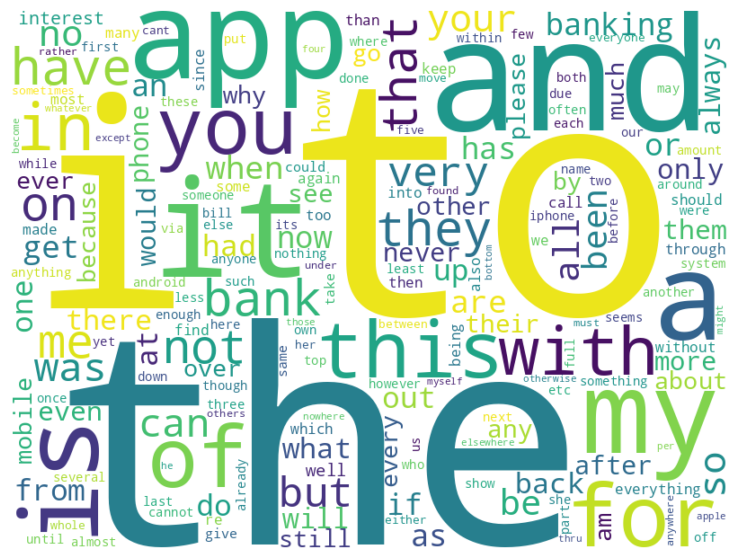

In [19]:
word_freq = dict(zip(removed_words["word"], removed_words["n"]))

wc = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=200
).generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

## 3.2 Preprocessing for Transformer Based

In [20]:
# Start from English-filtered data; select columns needed for transformer
df_transformer = df_english[['platform', 'storefront', 'rating', 'date',
                             'title', 'review', 'raw_text', 'source_file', 'bank']].copy()

print(f'Shape: {df_transformer.shape}')
df_transformer.head()

Shape: (4478, 9)


,platform,storefront,rating,date,title,review,raw_text,source_file,bank
0,iOS,us,3,2026-04-19 18:13:04-07:00,No ATM option,No debit card 😣,No ATM option No debit card 😣,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs
1,iOS,us,5,2026-04-17 13:06:01-07:00,Great Bank.,Really easy bank to use. The best interest rat...,Great Bank. Really easy bank to use. The best ...,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs
3,iOS,us,5,2026-04-16 16:11:11-07:00,Saving or CD,Easy to navigate and transfers back to account...,Saving or CD Easy to navigate and transfers ba...,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs
4,iOS,us,5,2026-04-16 06:48:48-07:00,Easy peasy,Very easy to use and efficient! Good interest...,Easy peasy Very easy to use and efficient! Go...,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs
5,iOS,us,3,2026-04-14 19:38:27-07:00,Needs widgets,I love the interface and how simple it is BUT ...,Needs widgets I love the interface and how sim...,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs


In [21]:
def rating_to_sentiment(r):
    if r <= 2:
        return 'negative'
    elif r == 3:
        return 'neutral'
    else:
        return 'positive'

df_transformer['sentiment'] = df_transformer['rating'].apply(rating_to_sentiment)
df_transformer['label'] = df_transformer['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

print(df_transformer['sentiment'].value_counts())
print(df_transformer['label'].value_counts())

sentiment
positive    2698
negative    1560
neutral      220
Name: count, dtype: int64
label
2    2698
0    1560
1     220
Name: count, dtype: int64


In [22]:
# For BERT: lowercase, remove URLs, normalize whitespace
# Punctuation is kept — BERT tokenizer handles it
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_transformer['text_clean'] = df_transformer['raw_text'].apply(clean_text)

# Drop empty rows after cleaning
df_transformer = df_transformer[df_transformer['text_clean'].str.len() > 0].reset_index(drop=True)

print(df_transformer[['raw_text', 'text_clean']].head(3))
print(f'\nFinal shape: {df_transformer.shape}')

                                            raw_text  \
0                      No ATM option No debit card 😣   
1  Great Bank. Really easy bank to use. The best ...   
2  Saving or CD Easy to navigate and transfers ba...   

                                          text_clean  
0                      no atm option no debit card 😣  
1  great bank. really easy bank to use. the best ...  
2  saving or cd easy to navigate and transfers ba...  

Final shape: (4478, 12)


count    4478.000000
mean       25.855293
std        30.580623
min         1.000000
25%         7.000000
50%        15.000000
75%        34.000000
max       377.000000
Name: text_length, dtype: float64

Reviews > 512 words: 0
Reviews > 256 words: 7
Reviews > 128 words: 62


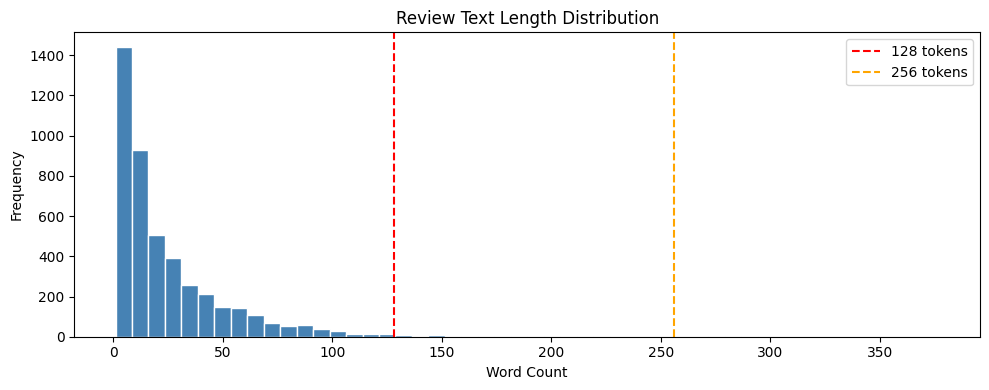

In [23]:
df_transformer['text_length'] = df_transformer['text_clean'].apply(lambda x: len(x.split()))

print(df_transformer['text_length'].describe())
print(f"\nReviews > 512 words: {(df_transformer['text_length'] > 512).sum()}")
print(f"Reviews > 256 words: {(df_transformer['text_length'] > 256).sum()}")
print(f"Reviews > 128 words: {(df_transformer['text_length'] > 128).sum()}")

plt.figure(figsize=(10, 4))
plt.hist(df_transformer['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(128, color='red', linestyle='--', label='128 tokens')
plt.axvline(256, color='orange', linestyle='--', label='256 tokens')
plt.title('Review Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150)
plt.show()